In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
data_path = "../data/raw/diabetic_data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully.
Number of rows: 101766
Number of columns: 50


In [6]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.columns 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [7]:
df["readmitted"].value_counts()
df["readmitted"].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

In [8]:
df["target"] = (df["readmitted"] == "<30").astype(int)

df["target"].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

In [9]:
df["target"].value_counts(normalize=True)

target
0    0.888401
1    0.111599
Name: proportion, dtype: float64

In [10]:
missing_values = (df == "?").sum().sort_values(ascending=False)

missing_values[missing_values > 0]

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [11]:
df.shape
df["readmitted"].value_counts()
df["target"].value_counts(normalize=True)
missing_values[missing_values > 0]

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [12]:
# Replace "?" by actual missing values
df = df.replace("?", np.nan)

missing_percentages = df.isna().mean().sort_values(ascending=False) * 100

missing_percentages[missing_percentages > 0]

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [13]:
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty",
    "race"
]

df_clean = df.drop(columns=columns_to_drop)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (101766, 51)
Cleaned shape: (101766, 47)


In [14]:
df_clean[["diag_1", "diag_2", "diag_3"]] = df_clean[["diag_1", "diag_2", "diag_3"]].fillna("Unknown")

df_clean.isna().sum().sum()

np.int64(181168)

### Missing values analysis

The dataset contains missing values encoded as "?". These values were first converted into actual missing values.

Some columns contain a very high proportion of missing values. The `weight` column is missing for most patients and was removed from the analysis.

The `payer_code` and `medical_specialty` columns were also removed in this first version because they contain many missing values and are not essential for a first baseline model.

The `race` column was removed because it is a sensitive attribute. This choice helps reduce the risk of introducing unfair bias into the model.

The diagnosis columns `diag_1`, `diag_2`, and `diag_3` contain fewer missing values. Their missing values were replaced by `"Unknown"`.

In [15]:
df_clean.shape
df_clean.isna().sum().sum()
df_clean["target"].value_counts(normalize=True)

target
0    0.888401
1    0.111599
Name: proportion, dtype: float64

### Target distribution

The target variable is imbalanced. Around 11% of patients were readmitted within 30 days, while around 89% were not.

This means that accuracy alone is not sufficient to evaluate the model. A model that always predicts the majority class would already obtain a high accuracy, but it would fail to identify high-risk patients.

For this reason, the project will focus on additional metrics such as recall, precision, F1-score, ROC-AUC, and the confusion matrix.

In a healthcare context, recall is especially important because missing high-risk patients can have serious consequences.

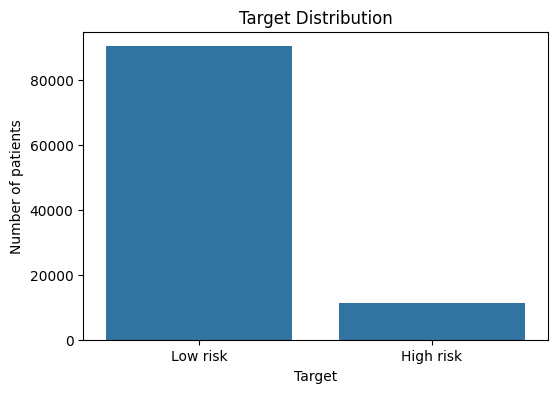

In [16]:
target_counts = df_clean["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of patients")
plt.xticks([0, 1], ["Low risk", "High risk"])
plt.show()

In [17]:
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

numeric_columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'target'],
      dtype='str')

In [18]:
df_clean[numeric_columns].describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,target
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000


In [19]:
important_numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df_clean[important_numeric_columns].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


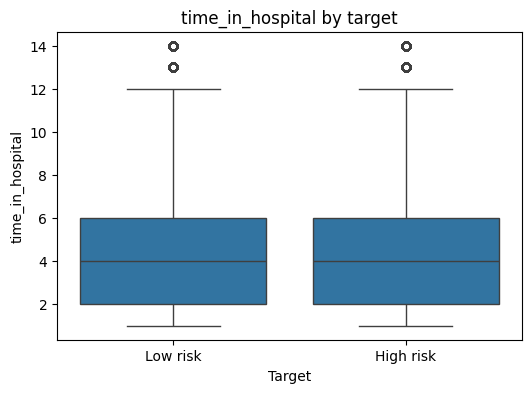

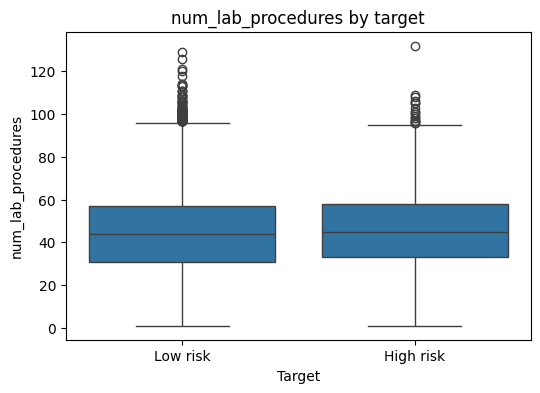

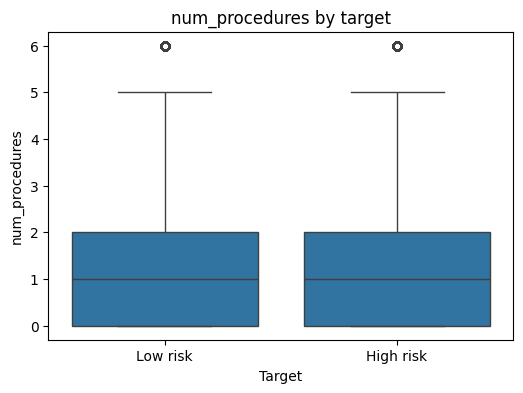

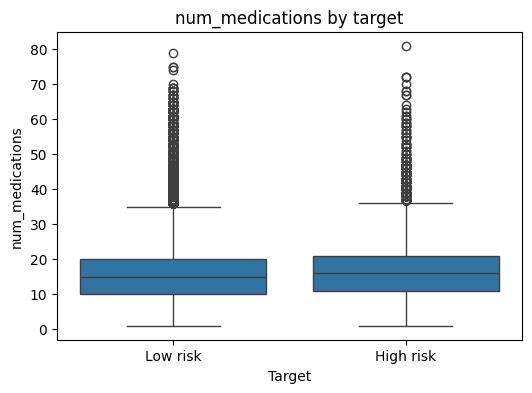

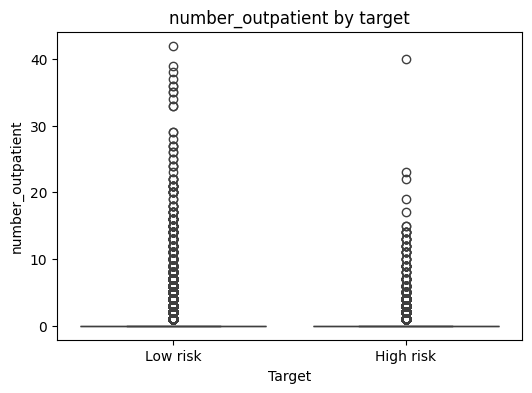

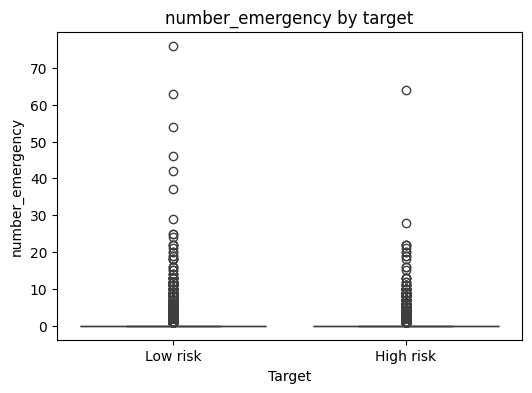

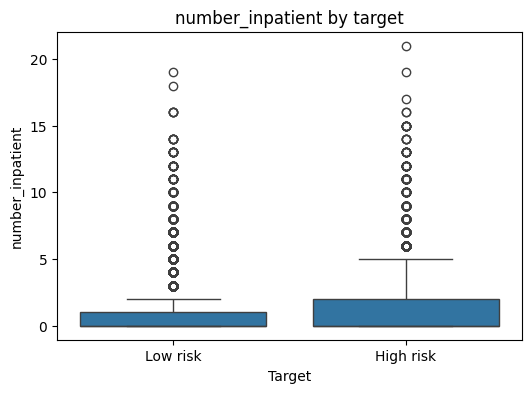

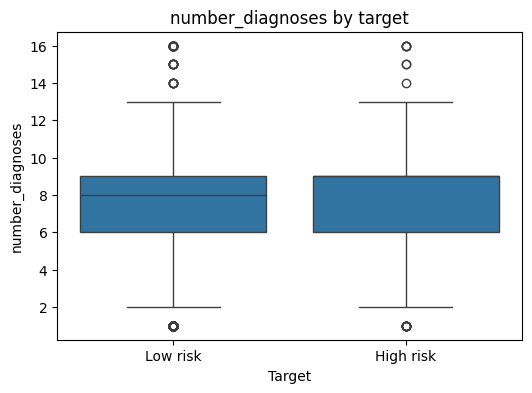

In [20]:
for column in important_numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_clean, x="target", y=column)
    plt.title(f"{column} by target")
    plt.xlabel("Target")
    plt.ylabel(column)
    plt.xticks([0, 1], ["Low risk", "High risk"])
    plt.show()

### Numerical features analysis

Several numerical variables describe the patient's hospital stay and previous healthcare usage.

The variables include the length of stay, the number of lab procedures, the number of medications, previous outpatient visits, emergency visits, inpatient admissions, and diagnoses.

Comparing these variables between low-risk and high-risk patients helps identify potential risk factors for early hospital readmission.

In [21]:
df_clean.groupby("target")[important_numeric_columns].mean()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
target,,,,,,,,
0,4.349224,42.953644,1.347123,15.911137,0.360871,0.177803,0.561648,7.388667
1,4.768249,44.226028,1.280884,16.903143,0.436911,0.357313,1.224003,7.692789


### Numerical feature comparison by target

Patients readmitted within 30 days tend to have higher values for several numerical variables.

The most notable difference is observed for `number_inpatient`: high-risk patients have, on average, more than twice as many previ
ous inpatient admissions compared to low-risk patients.

The variable `number_emergency` also appears higher among high-risk patients, suggesting that previous emergency visits may be associated with early readmission risk.

Other variables such as `time_in_hospital`, `num_medications`, and `number_diagnoses` are slightly higher for high-risk patients.

These first observations suggest that previous healthcare utilization is an important signal for predicting hospital readmission risk.
